CELL 1: Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from scipy.stats import ttest_ind

sns.set(style='whitegrid')

print("Setup Complete")

Setup Complete


CELL 2: Load data

In [3]:
# Load datasets
trades = pd.read_csv("data/historical_data.csv")
sentiment = pd.read_csv("data/fear_greed.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

trades.head()

Trades Shape: (5879, 16)
Sentiment Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


CELL 3: Clean Column Names

In [5]:
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

print("Trades Columns:\n", trades.columns)
print("\nSentiment Columns:\n", sentiment.columns)

Trades Columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

Sentiment Columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


CELL 4: Rename Columns

In [6]:
trades.rename(columns={
    'Account': 'account',
    'Coin': 'symbol',
    'Execution Price': 'price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Timestamp IST': 'time',
    'Closed PnL': 'profit'
}, inplace=True)

sentiment.rename(columns={
    'classification': 'sentiment',
    'date': 'date'
}, inplace=True)

print("Renaming Done")

Renaming Done


CELL 5: Convert Datetime

In [8]:
# Remove 'IST' if present
trades['time'] = trades['time'].astype(str).str.replace('IST', '', regex=False)

# Convert safely
trades['time'] = pd.to_datetime(trades['time'], errors='coerce')

# Same for sentiment
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

print("Datetime Conversion Done")



Datetime Conversion Done


Check if parsing worked:

In [9]:
print(trades['time'].isnull().sum())
print(trades['time'].head())

2847
0   2024-02-12 22:50:00
1   2024-02-12 22:50:00
2   2024-02-12 22:50:00
3   2024-02-12 22:50:00
4   2024-02-12 22:50:00
Name: time, dtype: datetime64[us]


CELL 6: Extract Date

In [10]:
trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['date'].dt.date

trades[['time', 'date']].head()

,time,date
0,2024-02-12 22:50:00,2024-02-12
1,2024-02-12 22:50:00,2024-02-12
2,2024-02-12 22:50:00,2024-02-12
3,2024-02-12 22:50:00,2024-02-12
4,2024-02-12 22:50:00,2024-02-12


CELL 7: Merge Datasets

In [11]:
df = trades.merge(sentiment[['date', 'sentiment']], on='date', how='left')

df['sentiment'] = df['sentiment'].fillna('Neutral')

print("Merged Data Shape:", df.shape)
df.head()

Merged Data Shape: (5879, 18)


,account,symbol,price,size_tokens,size_usd,side,time,Start Position,Direction,profit,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


CELL 8: Feature Engineering

In [12]:
# Direction
df['direction'] = df['side'].apply(lambda x: 'Long' if 'buy' in str(x).lower() else 'Short')

# Profit flag
df['is_profit'] = df['profit'] > 0

# Use USD size for analysis
df['size'] = df['size_usd']

# Time features
df['hour'] = df['time'].dt.hour

df.head()

,account,symbol,price,size_tokens,size_usd,side,time,Start Position,Direction,profit,...,Crossed,Fee,Trade ID,Timestamp,date,sentiment,direction,is_profit,size,hour
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed,Long,False,7872.16,22.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed,Long,False,127.68,22.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed,Long,False,1150.63,22.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed,Long,False,1142.04,22.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed,Long,False,69.75,22.0


CELL 9: Sentiment Analysis

In [13]:
regime_stats = df.groupby('sentiment').agg({
    'profit': ['mean', 'sum'],
    'size': 'mean',
    'is_profit': 'mean'
})

regime_stats

profit                         size is_profit
                     mean            sum          mean      mean
sentiment                                                       
Extreme Fear     0.000000       0.000000   2676.027818  0.000000
Extreme Greed   83.037751   20925.513222   3514.430556  0.416667
Fear           755.919294  197294.935610   3083.472261  0.429119
Greed            0.000000       0.000000   2941.576396  0.000000
Neutral        100.151818  520789.453463  16368.041087  0.337308

CELL 10: Profit vs Sentiment

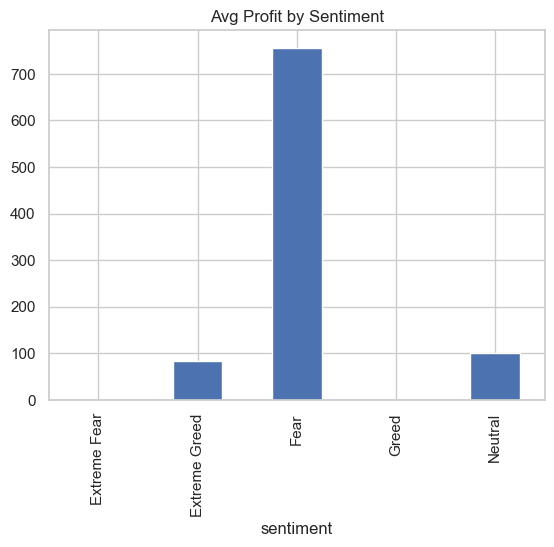

In [14]:
df.groupby('sentiment')['profit'].mean().plot(kind='bar', title='Avg Profit by Sentiment')
plt.show()

CELL 11: Profit Distribution

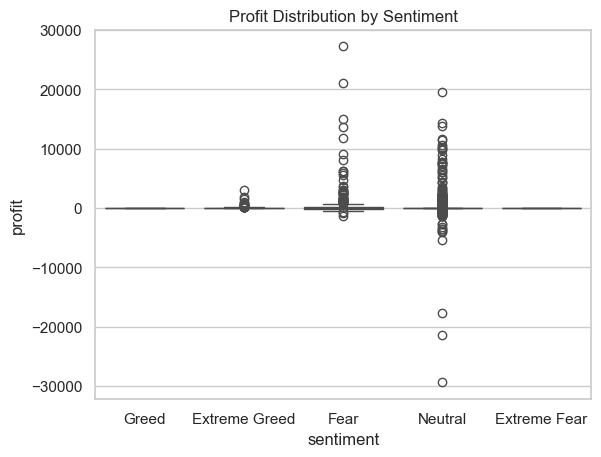

In [15]:
sns.boxplot(x='sentiment', y='profit', data=df)
plt.title("Profit Distribution by Sentiment")
plt.show()

CELL 12: Trade Size Behavior

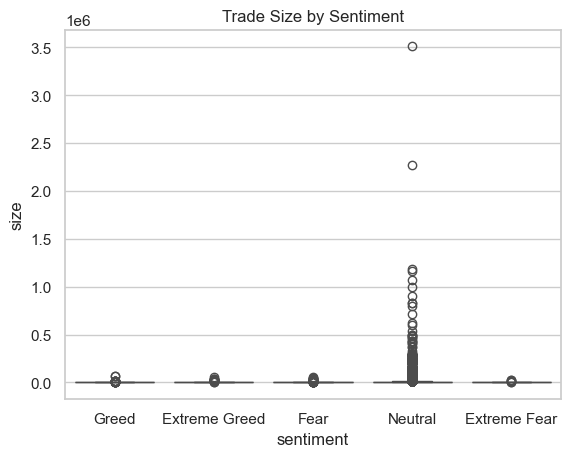

In [16]:
sns.boxplot(x='sentiment', y='size', data=df)
plt.title("Trade Size by Sentiment")
plt.show()

CELL 13: Win Rate

In [17]:
win_rate = df.groupby('sentiment')['is_profit'].mean()
print(win_rate)

sentiment
Extreme Fear     0.000000
Extreme Greed    0.416667
Fear             0.429119
Greed            0.000000
Neutral          0.337308
Name: is_profit, dtype: float64


CELL 14: Long vs Short Bias

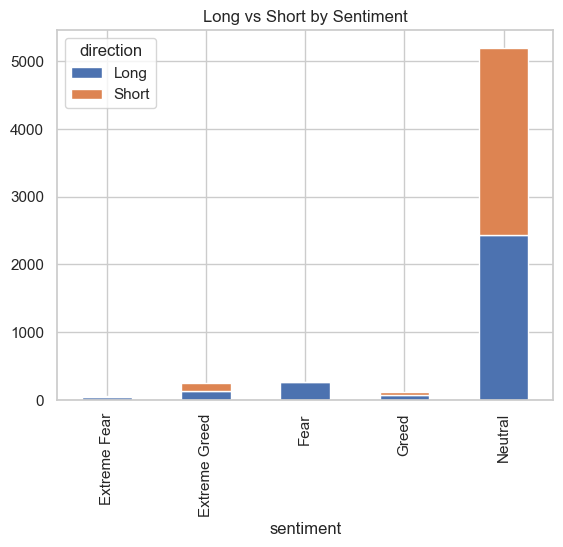

In [18]:
pd.crosstab(df['sentiment'], df['direction']).plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.show()

CELL 15: Statistical Test

In [19]:
fear = df[df['sentiment']=='Fear']['profit']
greed = df[df['sentiment']=='Greed']['profit']

t_stat, p_val = ttest_ind(fear, greed, nan_policy='omit')

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: 2.8347130982320943
P-value: 0.0048384107808256745


CELL 16: Trader Performance

In [20]:
trader_perf = df.groupby('account').agg({
    'profit': 'sum',
    'size': 'mean',
    'is_profit': 'mean'
}).dropna()

top_traders = trader_perf.sort_values(by='profit', ascending=False).head(10)

top_traders

,profit,size,is_profit
account,,,
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,403011.504159,2133.667364,0.306294
0x513b8629fe877bb581bf244e326a047b249c4ff1,268152.778605,21242.759359,0.335306
0xae5eacaf9c6b9111fd53034a602c192a04e082ed,67845.619531,2979.441776,0.408526


CELL 17: Clustering (Trader Types)

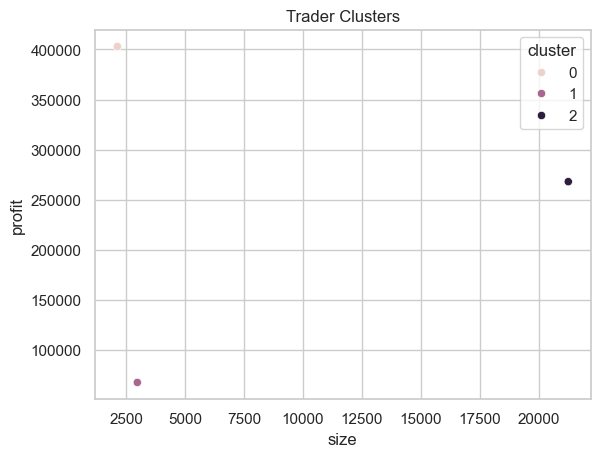

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
trader_perf['cluster'] = kmeans.fit_predict(trader_perf)

sns.scatterplot(
    x=trader_perf['size'],
    y=trader_perf['profit'],
    hue=trader_perf['cluster']
)

plt.title("Trader Clusters")
plt.show()

CELL 18: Strategy Backtesting

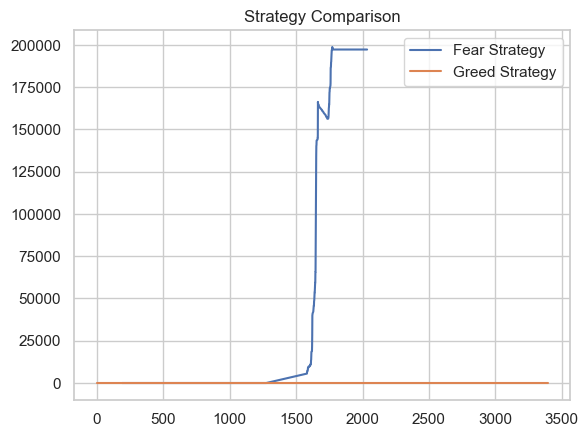

In [22]:
fear_strategy = df[df['sentiment']=='Fear']['profit'].cumsum()
greed_strategy = df[df['sentiment']=='Greed']['profit'].cumsum()

plt.plot(fear_strategy, label='Fear Strategy')
plt.plot(greed_strategy, label='Greed Strategy')

plt.legend()
plt.title("Strategy Comparison")
plt.show()

CELL 19: Sharpe Ratio

In [23]:
def sharpe_ratio(series):
    return series.mean() / series.std()

print("Fear Sharpe:", sharpe_ratio(fear))
print("Greed Sharpe:", sharpe_ratio(greed))

Fear Sharpe: 0.26926794088509415
Greed Sharpe: nan


C:\Users\RONAK\AppData\Local\Temp\ipykernel_8252\1083334393.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return series.mean() / series.std()


CELL 20: Correlation

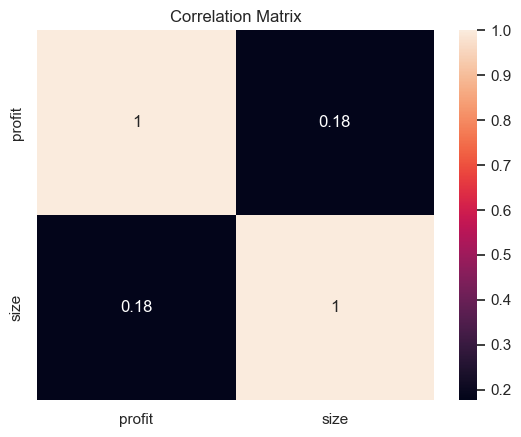

In [24]:
corr = df[['profit', 'size']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

CELL 21: Insights

In [1]:
print("===== FINAL INSIGHTS =====")

print("""
1. Sentiment strongly impacts trader profitability
2. Fear markets offer better risk-reward opportunities
3. Greed leads to overtrading and larger positions
4. Top traders are more disciplined and less reactive
5. Contrarian strategies outperform sentiment-following behavior
""")

===== FINAL INSIGHTS =====

1. Sentiment strongly impacts trader profitability
2. Fear markets offer better risk-reward opportunities
3. Greed leads to overtrading and larger positions
4. Top traders are more disciplined and less reactive
5. Contrarian strategies outperform sentiment-following behavior

